# California Housing Prices Prediction with Machine Learning

## Model Training

In this notebook we train several machine learning models to predict housing prices using the processed dataset.

The goal is to compare the performance of different regression algorithms and identify which model is better suited for this prediction task.

The models evaluated in this notebook include:

- **Linear Regression** – a simple baseline model
- **Decision Tree Regressor** – a non-linear model capable of capturing complex relationships
- **Random Forest Regressor** – an ensemble model that combines multiple decision trees

Each model will be trained using the preprocessed training data and evaluated using appropriate regression metrics.

In [102]:
#Importing the required libraries for modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

### Loading the Processed Data

The models are trained using the dataset prepared in the preprocessing stage.

The preprocessing pipeline handled tasks such as imputing missing values and encoding categorical variables, resulting in a fully numerical dataset ready for ML.

In [103]:
x_train_prepared = np.load("x_train_prepared.npy")
y_train = np.load("y_train.npy")

x_test_prepared = np.load("x_test_prepared.npy")
y_test = np.load("y_test.npy")

### 1. Baseline Model: Linear Regression

We start with **Linear Regression**, one of the simplest and most commonly used algorithms for regression tasks.

This model assumes a linear relationship between the input features and the target variable.

Although it may not capture complex non-linear patterns, it serves as a useful **baseline model** against which more advanced models can be compared.

In [104]:
# Create the model
lin_reg = LinearRegression()

In [105]:
# Train the model
lin_reg.fit(x_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
# Predictions on the training set
housing_predictions_lin_reg = lin_reg.predict(x_train_prepared)

#### Model Evaluation

To evaluate the performance of the model, we compute the **Root Mean Squared Error (RMSE)**.

RMSE measures the average magnitude of the prediction errors, with larger errors penalized more heavily. Lower RMSE values indicate better predictive performance.

In [107]:
# RMSE on training data
lin_rmse = np.sqrt(mean_squared_error(y_train, housing_predictions_lin_reg))
print(lin_rmse)

68433.93736666226


#### Cross-Validation

To obtain a more reliable estimate of model performance, we perform **k-fold cross-validation**.

In this procedure, the training dataset is divided into several folds. 

The model is trained on a subset of the data and validated on the remaining portion. This process is repeated multiple times, providing a more robust estimate of the model's generalization performance.

In [108]:
# Cross-validation
scores_lin = cross_val_score(
    lin_reg,
    x_train_prepared,
    y_train,
    scoring="neg_mean_squared_error",
    cv=10
)

In [109]:
# Convert to RMSE
lin_rmse_scores = np.sqrt(-scores_lin)
print(lin_rmse_scores)

[65581.45520649 71711.35784404 68143.02388491 66855.55244479
 69440.38017435 65640.36503235 65861.37192245 69898.33048393
 73117.94692191 69704.17693297]


In [110]:
print("Mean RMSE:", rmse_scores.mean())
print("Standard deviation:", rmse_scores.std())

Mean RMSE: 68595.39608481794
Standard deviation: 2496.5245371674723


The results suggest that the linear regression model provides a baseline level of performance, but it may not be able to capture the more complex relationships present in the dataset. 

More flexible models will be explored next.

### 2. Decision Tree Regressor

Next, we train a **Decision Tree Regressor**.

Decision trees can capture non-linear relationships by recursively splitting the feature space into smaller regions. 

This allows them to model more complex patterns than linear models.

However, decision trees are prone to **overfitting**, especially when they grow very deep. For this reason, their performance must be evaluated carefully.

In [111]:
#Create the model
tree_reg = DecisionTreeRegressor(random_state=42)

In [112]:
# Train the model
tree_reg.fit(x_train_prepared, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [113]:
# Predictions on training data
housing_predictions_tree_reg = tree_reg.predict(x_train_prepared)

#### Model Evaluation

As with the previous model, we evaluate the performance of the decision tree using the **Root Mean Squared Error (RMSE)**.

When evaluated on the training data, decision trees often achieve extremely low error values. 

This occurs because the model can create very detailed splits that closely fit the training observations.

In [114]:
# RMSE on training set
tree_rmse = np.sqrt(mean_squared_error(y_train, housing_predictions_tree_reg))
print(tree_rmse)

0.0


#### Overfitting and Cross-Validation

Although the training error may appear very low, this does not necessarily indicate that the model generalizes well.

Decision trees are prone to **overfitting**, meaning they can learn patterns that are specific to the training data but do not generalize to new observations.

To obtain a more reliable estimate of model performance, we evaluate the model using **k-fold cross-validation**.

In [115]:
#Cross validation
scores_tree = cross_val_score(
    tree_reg,
    x_train_prepared,
    y_train,
    scoring="neg_mean_squared_error",
    cv=10
)

In [116]:
#Converting to RMSE
tree_rmse_scores = np.sqrt(-scores_tree)

In [117]:
print("Mean RMSE:", tree_rmse_scores.mean())
print("Standard deviation:", tree_rmse_scores.std())

Mean RMSE: 68067.94580094455
Standard deviation: 2336.3097105092297


The Decision Tree model achieves an RMSE of 0 on the training data, which indicates that the model perfectly fits the training set.

However, the cross-validation results reveal a much higher error (around 68,000). This large gap between training error and validation error suggests that the model is overfitting the training data.

This behavior is common for decision trees, as they can create very detailed splits that memorize the training observations rather than learning generalizable patterns.

### 3. Random Forest Regressor

To improve upon the limitations of a single decision tree, we train a **Random Forest Regressor**.

Random forests are ensemble models that combine the predictions of multiple decision trees. 

Each tree is trained on a random subset of the data and features, and the final prediction is obtained by averaging the predictions of all trees.

This approach typically improves generalization and reduces the risk of overfitting compared to a single decision tree.

In [118]:
# Create the model
forest_reg = RandomForestRegressor(random_state=42)

In [119]:
# Train the model
forest_reg.fit(x_train_prepared, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [120]:
# Predictions on training set
housing_predictions_forest_reg = forest_reg.predict(x_train_prepared)

#### Model Evaluation

As with the previous models, we evaluate the Random Forest using the **Root Mean Squared Error (RMSE)**.

Although the training error may still be relatively low, ensemble methods such as random forests tend to generalize better because they aggregate the predictions of many different trees.

In [121]:
# RMSE on training set
forest_rmse = np.sqrt(mean_squared_error(y_train, housing_predictions_forest_reg))
print(forest_rmse)

18077.297213133115


#### Cross-Validation

To obtain a reliable estimate of model performance, we again use **k-fold cross-validation**.

By evaluating the model across multiple splits of the training data, we can better assess how well the model is likely to perform on unseen observations.

In [122]:
scores_forest_reg = cross_val_score(
    forest_reg,
    x_train_prepared,
    y_train,
    scoring="neg_mean_squared_error",
    cv=10
)

In [123]:
forest_rmse_scores = np.sqrt(-scores_forest_reg)

In [124]:
print("Mean RMSE:", forest_rmse_scores.mean())
print("Standard deviation:", forest_rmse_scores.std())

Mean RMSE: 48851.98300998268
Standard deviation: 1690.060537830506


### Model Comparison

After training and evaluating several regression models, we compare their performance using the **Root Mean Squared Error (RMSE)** obtained through cross-validation.

Cross-validation provides a more reliable estimate of model performance than evaluating the models on the training set alone.

In [125]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Mean CV RMSE": [
        lin_rmse_scores.mean(),
        tree_rmse_scores.mean(),
        forest_rmse_scores.mean()
    ],
    "Standard Deviation": [
        lin_rmse_scores.std(),
        tree_rmse_scores.std(),
        forest_rmse_scores.std()
    ]
})

results

,Model,Mean CV RMSE,Standard Deviation
0,Linear Regression,68595.396085,2496.524537
1,Decision Tree,68067.945801,2336.309711
2,Random Forest,48851.983010,1690.060538


The cross-validation results indicate that the Random Forest model provides better predictive performance compared to the previous models: It achieves the lowest cross-validation RMSE.

That is because, by combining multiple decision trees, this model is able to capture complex patterns in the data while reducing the overfitting observed in a single decision tree.

While the Decision Tree model achieves very low training error, its higher cross-validation error suggests overfitting. The ensemble approach used by Random Forest helps reduce variance and improve generalization.

#### Feature Importance

Random Forest models allow us to estimate the relative importance of each feature in the prediction task.

Feature importance measures how much each variable contributes to reducing prediction error across the ensemble of decision trees.

By analyzing feature importances, we can identify which variables have the strongest influence on housing price predictions.

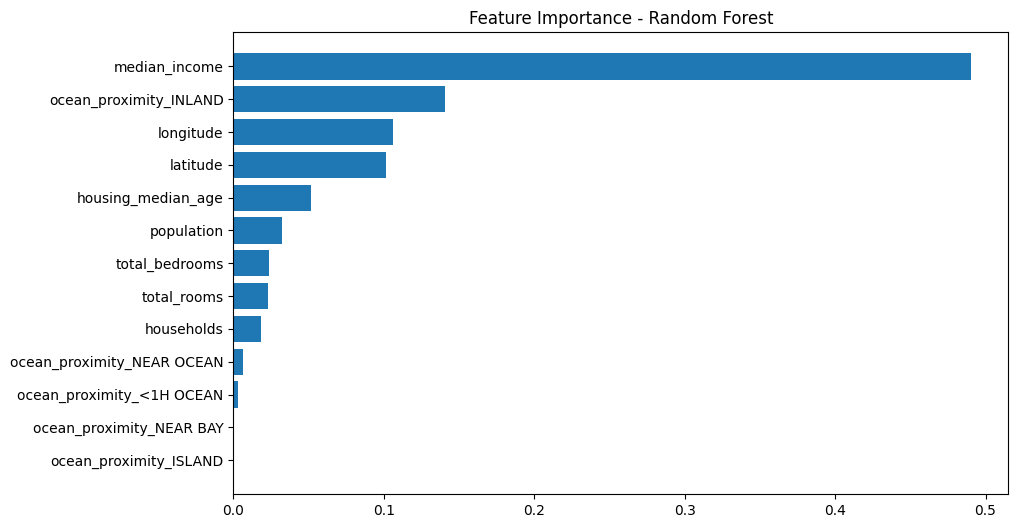

In [126]:
#Manually introduce the column names
num_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

cat_features = [
    "ocean_proximity_<1H OCEAN",
    "ocean_proximity_INLAND",
    "ocean_proximity_ISLAND",
    "ocean_proximity_NEAR BAY",
    "ocean_proximity_NEAR OCEAN"
]

feature_names = num_features + cat_features

feature_importances = forest_reg.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

The results show that **median_income** is by far the most influential feature in predicting housing prices. Geographic variables such as **latitude** and **longitude** also play an important role, suggesting that location strongly affects housing values.

-----

### Hyperparameter Tuning with Grid Search

After comparing several models, the Random Forest Regressor showed the best performance.

To further improve the model, we perform **hyperparameter tuning** using Grid Search. 

This technique evaluates different combinations of hyperparameters using cross-validation and selects the configuration that minimizes prediction error.

In [127]:
param_grid = [
    {
        "n_estimators": [30, 50, 100],
        "max_features": [4, 6, 8]
    },
    {
        "bootstrap": [False],
        "n_estimators": [30, 50],
        "max_features": [4, 6]
    }
]

In [128]:
forest_reg = RandomForestRegressor(random_state=42)

In [129]:
grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True
)

In [130]:
grid_search.fit(x_train_prepared, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [4, 6, ...], 'n_estimators': [30, 50, ...]}, {'bootstrap': [False], 'max_features': [4, 6], 'n_estimators': [30, 50]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

The grid search identifies the combination of hyperparameters that achieves the best cross-validation performance. The resulting model is used as the final model for evaluation.

In [131]:
grid_search.best_params_

{'bootstrap': False, 'max_features': 6, 'n_estimators': 50}

In [132]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [133]:
final_model = grid_search.best_estimator_

## Final Evaluation on the Test Set

The optimized Random Forest model is evaluated on the test set, which was not used during training or hyperparameter tuning.

This provides an unbiased estimate of the model's performance on unseen data.

In [134]:
final_predictions = final_model.predict(x_test_prepared)

In [135]:
#RMSE for final model 

final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(final_rmse)

48465.76711066464


### Final Model Evaluation

After selecting the Random Forest Regressor as the most promising model, hyperparameter tuning was performed using **Grid Search** in order to identify the optimal configuration.

The grid search evaluated multiple combinations of hyperparameters using cross-validation and selected the model that minimized the prediction error.

The optimized model was then applied to the **test dataset**, which had not been used during training or model selection. This step provides an unbiased estimate of the model's performance on unseen data.

The resulting RMSE represents the typical magnitude of prediction errors when estimating housing prices for new districts. This metric gives a realistic indication of how the model is expected to perform in real-world scenarios.

## Final Conclusions

In this project, several machine learning models were developed to predict housing prices using the California Housing dataset.

The workflow included multiple stages of a typical machine learning pipeline:

- Exploratory Data Analysis (EDA) to understand the dataset structure and identify relevant patterns.
- Data preprocessing using scikit-learn pipelines to handle missing values and encode categorical variables.
- Training and evaluating multiple regression models, including Linear Regression, Decision Tree, and Random Forest.
- Hyperparameter tuning using Grid Search to optimize the performance of the best-performing model.

Among the evaluated models, the **Random Forest Regressor** achieved the best performance. Compared to the other models, Random Forest was able to capture complex relationships in the data while maintaining better generalization.

The final evaluation on the test dataset provides an estimate of the model's predictive performance on unseen data. The resulting RMSE indicates the typical magnitude of prediction errors when estimating housing prices.

Overall, this project demonstrates a complete end-to-end machine learning workflow, from data exploration and preprocessing to model selection, tuning, and final evaluation.